In [88]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import networkx as nx
from collections import Counter
from itertools import combinations
import community.community_louvain as community_louvain
import re
from wordcloud import WordCloud, STOPWORDS
import plotly.express as px
import plotly.graph_objects as go
import numpy as np

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
scopus = pd.read_csv('/content/drive/MyDrive/Maestria/Semestre 3/Seminario II/Review/Nuevo/scopus.csv')
agris = pd.read_csv('/content/drive/MyDrive/Maestria/Semestre 3/Seminario II/Review/Nuevo/agris.csv')
scholar = pd.read_csv('/content/drive/MyDrive/Maestria/Semestre 3/Seminario II/Review/Nuevo/GoogleScholar.csv')
wos = pd.read_csv('/content/drive/MyDrive/Maestria/Semestre 3/Seminario II/Review/Nuevo/WOS1.csv', sep=';')

In [4]:
wos = wos[['Authors','Article Title','Publication Year','Source Title','Abstract']]
wos.columns = ['Authors','Title','Year','Source title','Abstract']

In [5]:
data = pd.concat([scopus,agris],axis=0)
len(data)

74

In [6]:
data['dup_key'] = (
    data['Title'].str.strip().str.lower() + '_' +
    data['Authors'].str.strip().str.lower() + '_' +
    data['Year'].astype(str) + '_' +
    data['Source title'].str.strip().str.lower()
)

data = data.drop_duplicates(subset=['dup_key'], keep='first')
len(data)

69

In [7]:
data = pd.concat([data,scholar],axis=0)
print(len(data))
data = data.drop_duplicates(subset=['Title'], keep='first')
print(len(data))

88
88


In [8]:
data = pd.concat([data,wos],axis=0)
print(len(data))
data = data.drop_duplicates(subset=['Title'], keep='first')
print(len(data))

136
129


In [9]:
revisar = data.tail(41)
revisar.to_excel('/content/drive/data_to_check.xlsx')

In [13]:
data = pd.read_excel('/content/drive/Final_after_review.xlsx')
data.columns

Index(['Unnamed: 0', 'Authors', 'Author full names', 'Author(s) ID', 'Title',
       'Year', 'Source title', 'Volume', 'Issue', 'Art. No.', 'Page start',
       'Page end', 'Page count', 'Cited by', 'DOI', 'Link', 'Affiliations',
       'Authors with affiliations', 'Abstract', 'Author keywords',
       'Index Keywords', 'Molecular Sequence Numbers', 'Chemicals/CAS',
       'Tradenames', 'Manufacturers', 'Funding Details', 'Funding Texts',
       'References', 'Correspondence Address', 'Editors', 'Publisher',
       'Sponsors', 'Conference name', 'Conference date', 'Conference location',
       'Conference code', 'ISSN', 'ISBN', 'CODEN', 'PubMed ID',
       'Language of Original Document', 'Abbreviated Source Title',
       'Document Type', 'Publication Stage', 'Open Access', 'Source', 'EID',
       'Country', 'Group', 'Model', 'Other variables', 'temp_range',
       'temp_value', 'humidity', 'rainfall', 'wind_speed', 'accuracy', 'r2',
       'rmse', 'standard_error', 'Disease', 'Coment

In [111]:
abstracts = data['Abstract']

patterns = {
    "temp_range": r'([<>]?\s*\d{1,2}(?:\.\d+)?)[° ]*[–\-to]+\s*([<>]?\s*\d{1,2}(?:\.\d+)?)\s*°?C',
    "temp_value": r'(?:temperature[s]?(?:\s+in\s+the\s+range)?[^\d]{0,20})[<>]?\s*(\d{1,2}(?:\.\d+)?)\s*°?C',
    "humidity": r'([<>]?\s*\d{1,3})\s*[-–to]+\s*([<>]?\s*\d{1,3})\s*%|RH\s*[=<>]?\s*(\d{1,3})\s*%?',
    "rainfall": r'([<>]?\s*\d{1,3}(?:\.\d+)?)\s*[-–to]+\s*([<>]?\s*\d{1,3}(?:\.\d+)?)\s*mm',
    "wind_speed": r'([<>]?\s*\d+(?:\.\d+)?)\s*[-–to]+\s*([<>]?\s*\d+(?:\.\d+)?)\s*(?:km/?h|Km/h)',
    "accuracy": r'accuracy(?:\s+of)?\s*[=<>]?\s*(\d{1,3}(?:\.\d+)?)\s*%',
    "r2": r'R\s?[²2]?\s*[=<>]?\s*(\d(?:\.\d+)?)',
    "rmse": r'RMSE[^\d\-]*(\d+(?:\.\d+)?)',
    "standard_error": r'(?:standard\s+error|SE|±)\s*=?\s*(\d+(?:\.\d+)?)',
}

def extract_all(text, patterns):
    results = {}
    for key, pattern in patterns.items():
        matches = re.findall(pattern, str(text), flags=re.IGNORECASE)
        if matches:
            if isinstance(matches[0], tuple):
                results[key] = [", ".join(m for m in tup if m.strip()) for tup in matches if any(m.strip() for m in tup)]
            else:
                results[key] = matches
        else:
            results[key] = []
    return results

extracted_data = abstracts.apply(lambda x: extract_all(x, patterns))
df_extracted = pd.DataFrame(extracted_data.tolist())
df_extracted


,temp_range,temp_value,humidity,rainfall,wind_speed,accuracy,r2,rmse,standard_error
0,"[ 16, 18, 16, 18]",[],[],[],[],[],"[0.632, 0.577, 0.61, 0.46, 0.46, 0, 0, 0, 0, 0]",[],[]
1,"[ 15.0, 28.0, 2.0, 12.0]",[],[],"[ 15.5, 20.75]",[],[],[],[],[]
2,"[ 3, 30]",[],"[ 45, 100, 15, 35]",[],[],[],[],[],[]
3,[],[],[],[],[],[],[],[],[]
4,[],[27],[],[],[],[],[],[],[]
...,...,...,...,...,...,...,...,...,...
56,[],[],[],[],[],[],[],[],[]
57,[],[],[],[],[],[],[2],"[1.17, 8.0]",[]
58,[],[],[],[],[],[],[],[],[]
59,[],[],[],[],[],[],[],[],[]


In [11]:
data = data.reset_index(drop=True)

In [12]:
final = pd.concat([data,df_extracted],axis=1)

In [15]:
data

,Unnamed: 0,Authors,Author full names,Author(s) ID,Title,Year,Source title,Volume,Issue,Art. No.,...,temp_value,humidity,rainfall,wind_speed,accuracy,r2,rmse,standard_error,Disease,Comentarios
0,0.0,Nyankanga R.O.; Wien H.C.; Olanya O.M.; Ojiamb...,"Nyankanga, R.O. (24073720200); Wien, H.C. (660...",24073720200; 6602397326; 6603178794; 6602313707,Relationship between late blight [Phytophthora...,2007,Canadian Journal of Plant Pathology,29.0,4,NaN,...,[],[],[],[],[],"['0.632', '0.577', '0.61', '0.46', '0.46']",[],[],Phytophthora infestans,El modelo es deterministico pero usan metodos ...
1,1.0,Dar W.A.; Parry F.A.; Bhat B.A.,"Dar, W.A. (55778331700); Parry, F.A. (57189758...",55778331700; 57189758670; 36916502700,Potato late blight disease prediction using me...,2021,Journal of Agrometeorology,23.0,3,NaN,...,[],[],"['15.5, 20.75']","['1, 5.5']",[],"['0.79', '0.82]","['0.58', '0.78']",[],Phytophthora infestans,RMSE
2,3.0,Modesto O.O.; Anwar M.; He Z.; Larkin R.P.; Ho...,"Modesto, Olanya Ocen (57148154400); Anwar, Moh...",57148154400; 24314797200; 26642988500; 5720592...,Survival potential of Phytophthora infestans s...,2016,Journal of Plant Protection Research,56.0,1,NaN,...,[],"[' 45, 100']",[],[],[],[],[],[],Phytophthora infestans,Sporangia survival
3,4.0,MICHAELIDES S.C.,"MICHAELIDES, S.C. (57202409199)",57202409199,A dynamic model of the interactions between th...,1991,EPPO Bulletin,21.0,3,NaN,...,[],"[' 75, 100']",[],[],[],[],[],[],Phytophthora infestans,NaN
4,5.0,Henderson D.; Williams C.J.; Miller J.S.,"Henderson, Donna (54582429200); Williams, Chri...",54582429200; 56108938100; 55547119620,Forecasting late blight in potato crops of sou...,2007,Plant Disease,91.0,8,NaN,...,['27'],"['80, 100']",[],[],"['67.5, 80']",[],[],[],Phytophthora infestans,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56,22.0,"Gu Y. H., Yoo S. J., Park C. J., Kim Y. H., Pa...",NaN,NaN,BLITE-SVR: New forecasting model for late blig...,2016,COMPUTERS AND ELECTRONICS IN AGRICULTURE,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
57,25.0,"Wu Qiang, Yang Yuan-yan, Andom Okbagaber, Li Y...",NaN,NaN,Effectiveness of potato late blight (Phytophth...,2023,FUNGAL BIOLOGY,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
58,26.0,"Small Ian M., Joseph Laura, Fry William E.",NaN,NaN,Development and implementation of the BlightPr...,2015,COMPUTERS AND ELECTRONICS IN AGRICULTURE,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
59,30.0,"Iglesias Isabel, Escuredo Olga, Seijo Carmen, ...",NaN,NaN,Phytophthora infestans Prediction for a Potato...,2010,AMERICAN JOURNAL OF POTATO RESEARCH,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
plt.rcParams['font.family'] = 'Times New Roman'

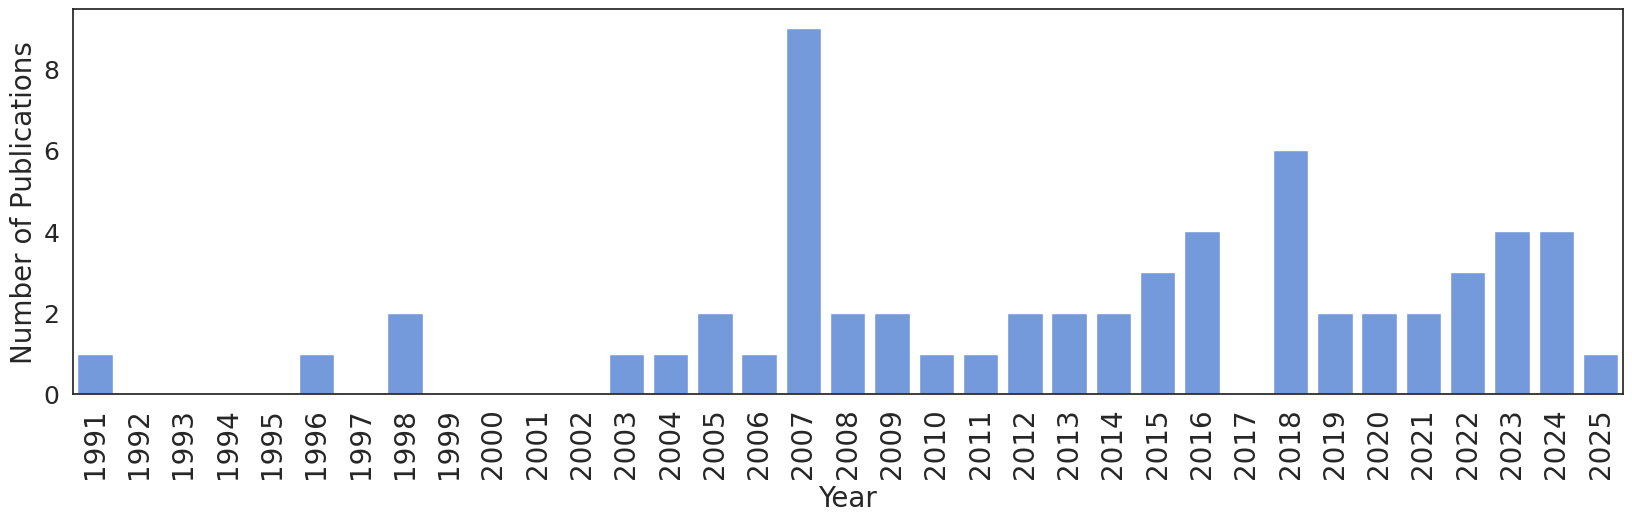

In [17]:
all_years = pd.DataFrame({'Year': range(1976, 2025)})
all_years['Year'] = all_years['Year'].astype(int)
años = data['Year']
años = años.dropna()
publication_counts = años.value_counts().reset_index()
publication_counts.columns = ['Year', 'count']
all_years['Year'] = all_years['Year'].astype(str)
publication_counts = publication_counts[publication_counts['Year']!='0']
all_years = all_years.astype(int)
publication_counts = publication_counts.astype(int)

full_data = pd.merge(all_years, publication_counts, on='Year', how='outer')
full_data = full_data.fillna(0)

full_data['count'] = full_data['count'].astype(int)
full_data['Year'] = full_data['Year'].astype(int)
full_data = full_data.sort_values(by='Year',ascending=True)
full_data = full_data[full_data['Year']>=1991]
sns.set_theme(style='white')
plt.figure(figsize=(20, 5))
sns.barplot(data=full_data, x='Year', y='count',color='cornflowerblue')
plt.xticks(rotation=90, fontsize=20)
plt.yticks( fontsize=18)
plt.xlabel('Year', fontsize=20)
plt.ylabel('Number of Publications', fontsize=20)
plt.show()

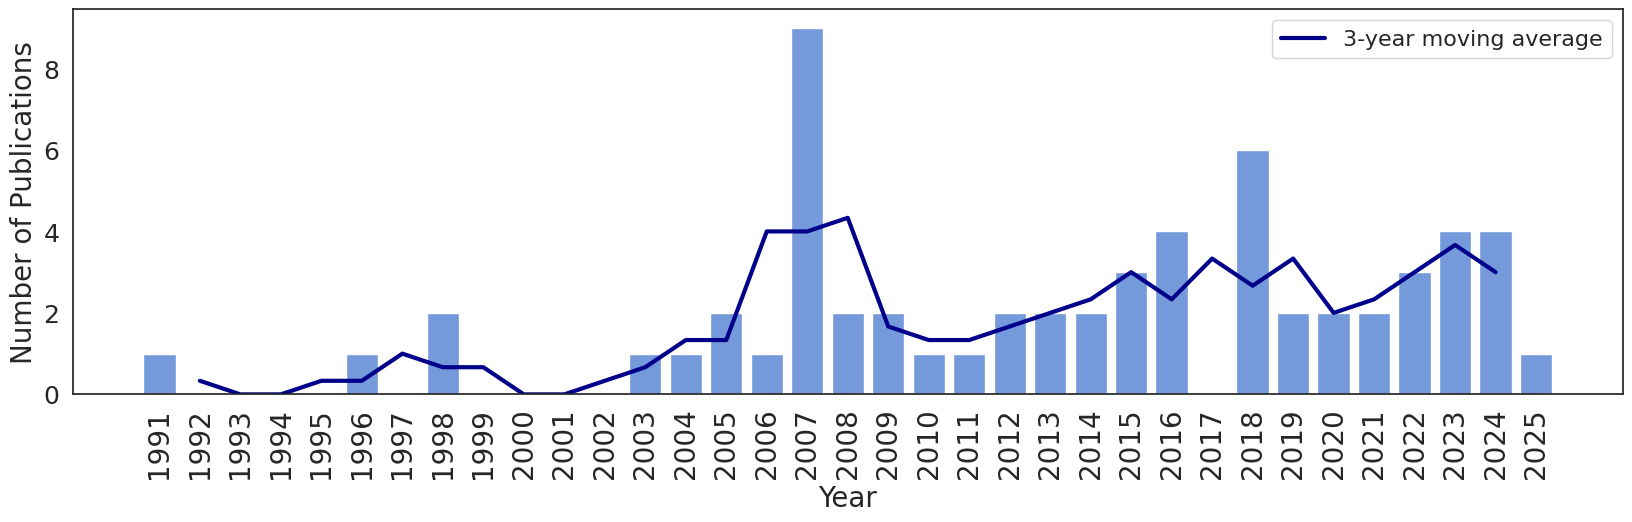

In [27]:
full_data['trend'] = full_data['count'].rolling(window=3, center=True).mean()
fig, ax = plt.subplots(figsize=(20,5))
sns.barplot(data=full_data,x='Year',y='count',color='cornflowerblue',ax=ax)

ax.plot(range(len(full_data)),full_data['trend'],color='darkblue',linewidth=3,label='3-year moving average')
plt.xlabel('Year', fontsize=20)
plt.ylabel('Number of Publications', fontsize=20)
plt.yticks( fontsize=18)
plt.xticks(rotation=90, fontsize=20)
ax.legend(fontsize=16)

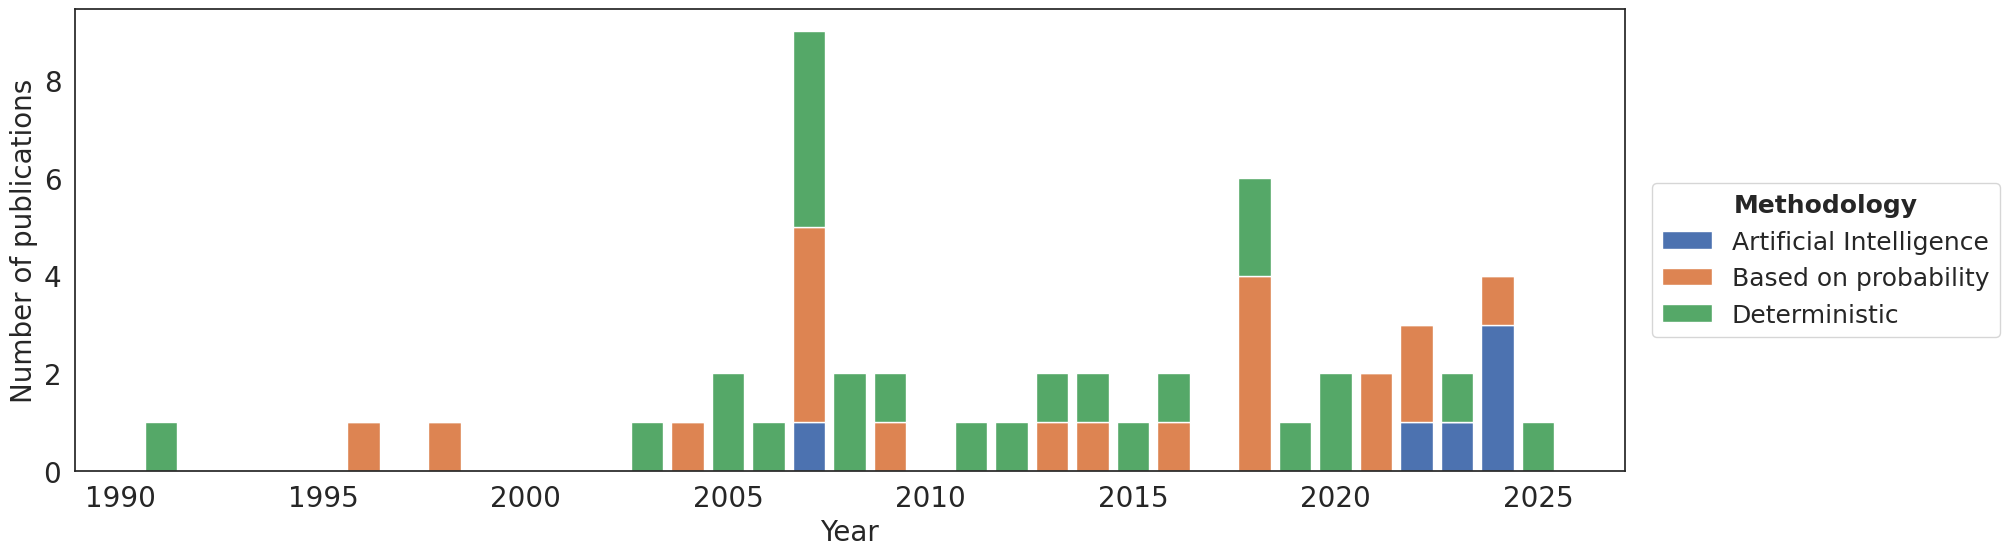

In [35]:
counts = data.groupby(['Year', 'Group']).size().reset_index(name='count')
pivot_counts = counts.pivot(index='Year', columns='Group', values='count').fillna(0)
pivot_counts = pivot_counts.sort_index()
pivot_counts = pivot_counts[pivot_counts.index >= 1991]
plt.figure(figsize=(20, 6))
bottom = pd.Series([0]*len(pivot_counts), index=pivot_counts.index)

for grupo in pivot_counts.columns:
    plt.bar(pivot_counts.index, pivot_counts[grupo], bottom=bottom, label=grupo)
    bottom += pivot_counts[grupo]

plt.xlabel('Year', fontsize=20)
plt.ylabel('Number of publications', fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
leg = plt.legend(title='Methodology', fontsize=18, bbox_to_anchor=(1.25, 0.65))
leg.get_title().set_fontweight('bold')
leg.get_title().set_fontsize(18)
plt.show()

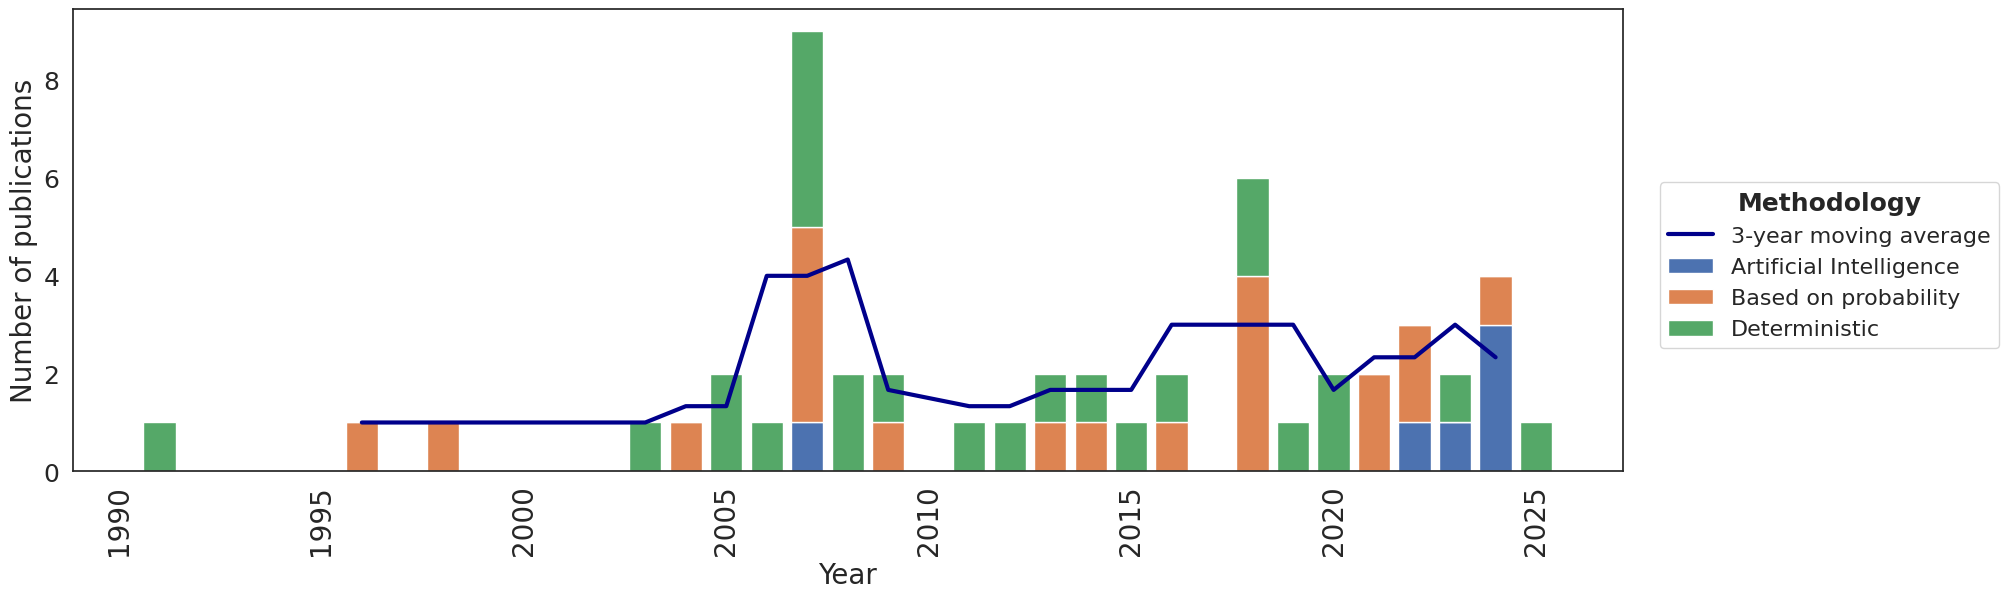

In [107]:
counts = data.groupby(['Year', 'Group']).size().reset_index(name='count')

pivot_counts = counts.pivot(index='Year', columns='Group', values='count').fillna(0)
pivot_counts = pivot_counts.sort_index()
pivot_counts = pivot_counts[pivot_counts.index >= 1991]

full_data = pivot_counts.sum(axis=1).reset_index(name='total')
full_data['trend'] = full_data['total'].rolling(window=3, center=True).mean()

fig, ax = plt.subplots(figsize=(20, 6))

bottom = pd.Series([0]*len(pivot_counts), index=pivot_counts.index)

for grupo in pivot_counts.columns:
    ax.bar(
        pivot_counts.index,
        pivot_counts[grupo],
        bottom=bottom,
        label=grupo
    )
    bottom += pivot_counts[grupo]

ax.plot(
    full_data['Year'],
    full_data['trend'],
    color='darkblue',
    linewidth=3,
    label='3-year moving average'
)

ax.set_xlabel('Year', fontsize=20)
ax.set_ylabel('Number of publications', fontsize=20)

ax.tick_params(axis='x', rotation=90, labelsize=20)
ax.tick_params(axis='y', labelsize=18)

handles, labels = ax.get_legend_handles_labels()

trend_idx = labels.index('3-year moving average')

trend_handle = handles.pop(trend_idx)
trend_label = labels.pop(trend_idx)

handles = [trend_handle] + handles
labels = [trend_label] + labels

leg = ax.legend(
    handles,
    labels,
    title='Methodology',
    fontsize=16,
    bbox_to_anchor=(1.25, 0.65)
)

leg.get_title().set_fontweight('bold')
leg.get_title().set_fontsize(18)

plt.show()

In [38]:
from matplotlib.font_manager import FontProperties
font_italic = FontProperties()
font_italic.set_style('italic')
font_italic.set_size(20)

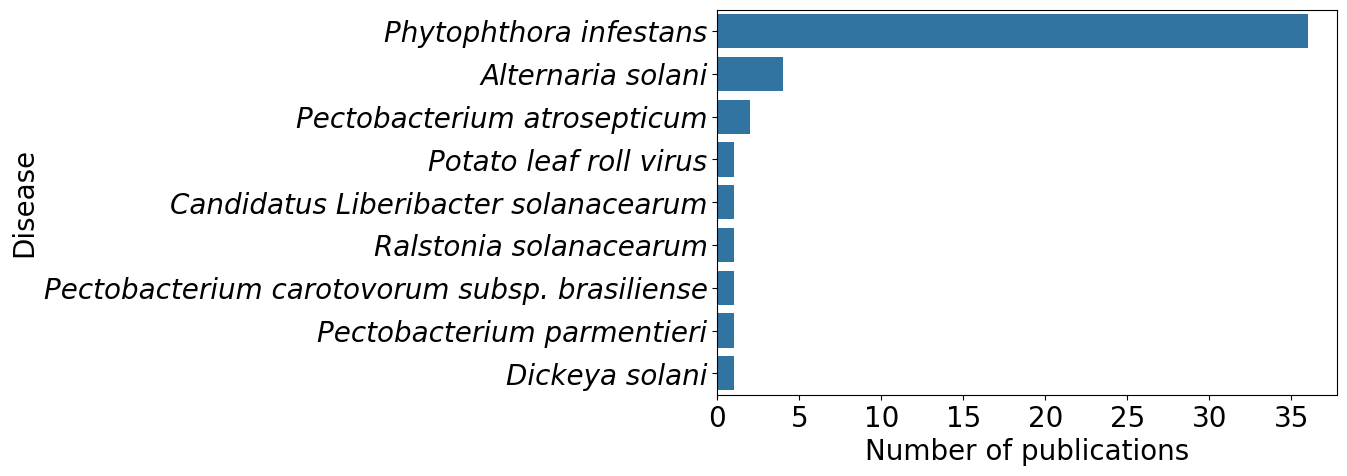

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(data=data,y='Disease',order=data['Disease'].value_counts().index)
plt.ylabel('Disease', fontsize=20)
plt.xlabel('Number of publications', fontsize=20)
plt.yticks(fontsize=20, fontproperties=font_italic)
plt.xticks(fontsize=20)
plt.show()

/tmp/ipykernel_7074/289731083.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([format_label(t.get_text()) for t in ax.get_yticklabels()])


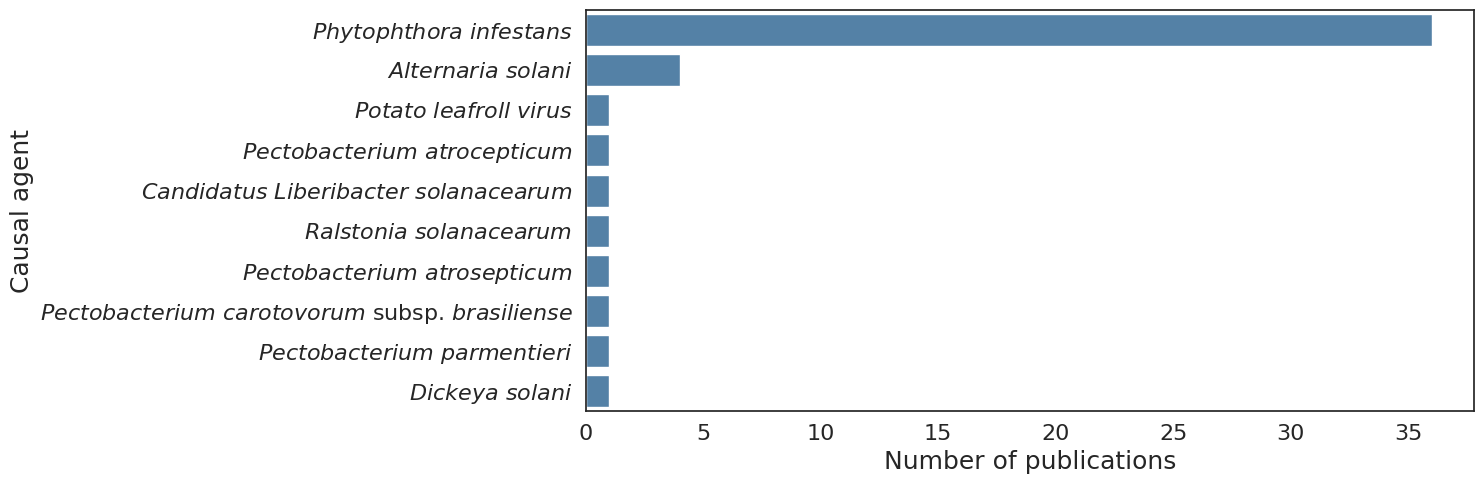

In [53]:
data['Disease'] = data['Disease'].replace({
    'Potato leaf roll virus': 'Potato leafroll virus'
})

order = data['Disease'].value_counts().index
sns.set_theme(style="white")
plt.figure(figsize=(15, 5))

ax = sns.countplot(data=data, y='Disease', order=order,color='steelblue')

ax.set_xlabel('Number of publications', fontsize=18)
ax.set_ylabel('Causal agent', fontsize=18)

ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)

def format_label(text):
    if text == 'Candidatus Liberibacter solanacearum':
        return r"$\it{Candidatus\ } Liberibacter\ solanacearum$"
    if 'subsp.' in text:
        parts = text.split('subsp.')
        left = r'\ '.join(parts[0].strip().split())
        right = r'\ '.join(parts[1].strip().split())

        return rf"$\it{{{left}}}$ subsp. $\it{{{right}}}$"

    words = text.split()
    italic = r'\ '.join(words)

    return rf"$\it{{{italic}}}$"

ax.set_yticklabels([format_label(t.get_text()) for t in ax.get_yticklabels()])

plt.tight_layout()
plt.show()

In [ ]:
data['Disease'].value_counts()

,count
Disease,
Phytophthora infestans,36
Alternaria solani,4
Pectobacterium atrosepticum,2
Potato leaf roll virus,1
Candidatus Liberibacter solanacearum,1
Ralstonia solanacearum,1
Pectobacterium carotovorum subsp. brasiliense,1
Pectobacterium parmentieri,1
Dickeya solani,1


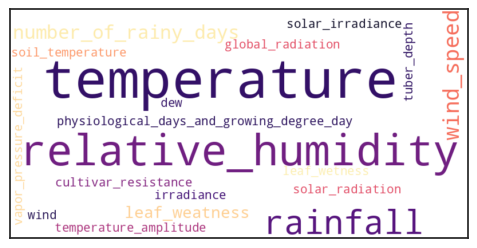

In [57]:
terms = []
for entry in data['Other variables'].dropna():
    split_terms = [term.strip() for term in entry.split(';')]
    split_terms_underscored = [term.replace(' ', '_') for term in split_terms]
    terms.extend(split_terms_underscored)
text = " ".join(terms)
stopwords = set(STOPWORDS)
stopwords.update(["based", "on", "T"])
wordcloud = WordCloud(
    stopwords=stopwords,
    background_color="white",
    colormap='magma',
    width=800,
    height=400,
    collocations=False,
    contour_width=3,
    contour_color='black'
).generate(text)
plt.figure(figsize=(5, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.tight_layout(pad=0)
plt.xticks([])
plt.yticks([])
plt.show()

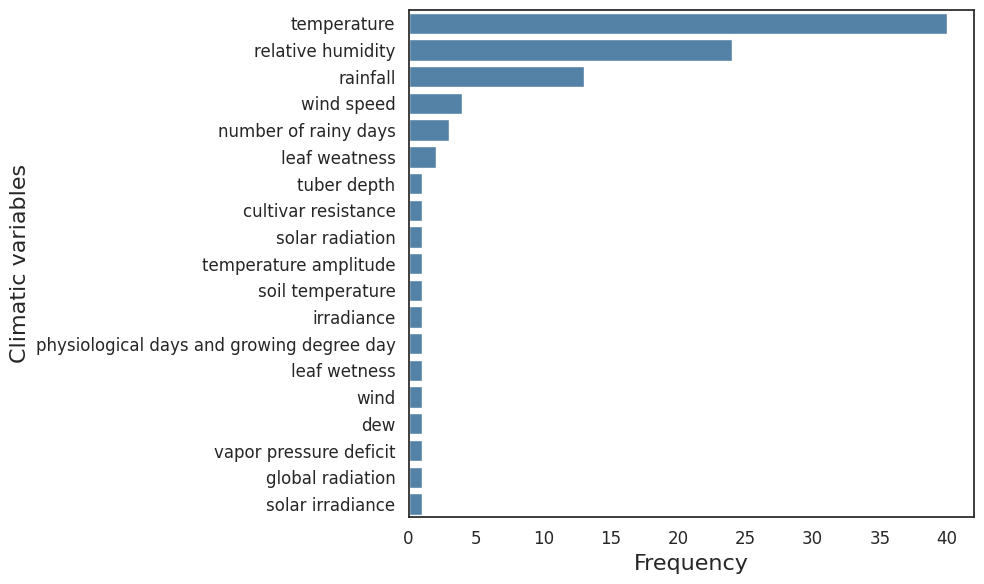

In [61]:
freq = pd.Series(terms).value_counts().reset_index()
freq.columns = ['Term', 'Frequency']

top_n = 20
freq = freq.head(top_n)
freq['Term'] = freq['Term'].str.replace('_', ' ', regex=False)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=freq,
    x='Frequency',
    y='Term',
    color='steelblue'
)

ax.set_xlabel('Frequency', fontsize=16)
ax.set_ylabel('Climatic variables', fontsize=16)
ax.tick_params(axis='both', labelsize=12)

plt.tight_layout()
plt.show()

In [62]:
data["Authors"] = data["Authors"].str.replace(r"\.(?=;|,)", "", regex=True)
data["Authors"]

,Authors
0,Nyankanga R.O; Wien H.C; Olanya O.M; Ojiambo P.S.
1,Dar W.A; Parry F.A; Bhat B.A.
2,Modesto O.O; Anwar M; He Z; Larkin R.P; Honeyc...
3,MICHAELIDES S.C.
4,Henderson D; Williams C.J; Miller J.S.
...,...
56,"Gu Y. H, Yoo S. J, Park C. J, Kim Y. H, Park S..."
57,"Wu Qiang, Yang Yuan-yan, Andom Okbagaber, Li Y..."
58,"Small Ian M, Joseph Laura, Fry William E."
59,"Iglesias Isabel, Escuredo Olga, Seijo Carmen, ..."


/tmp/ipykernel_7074/3671421316.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels)


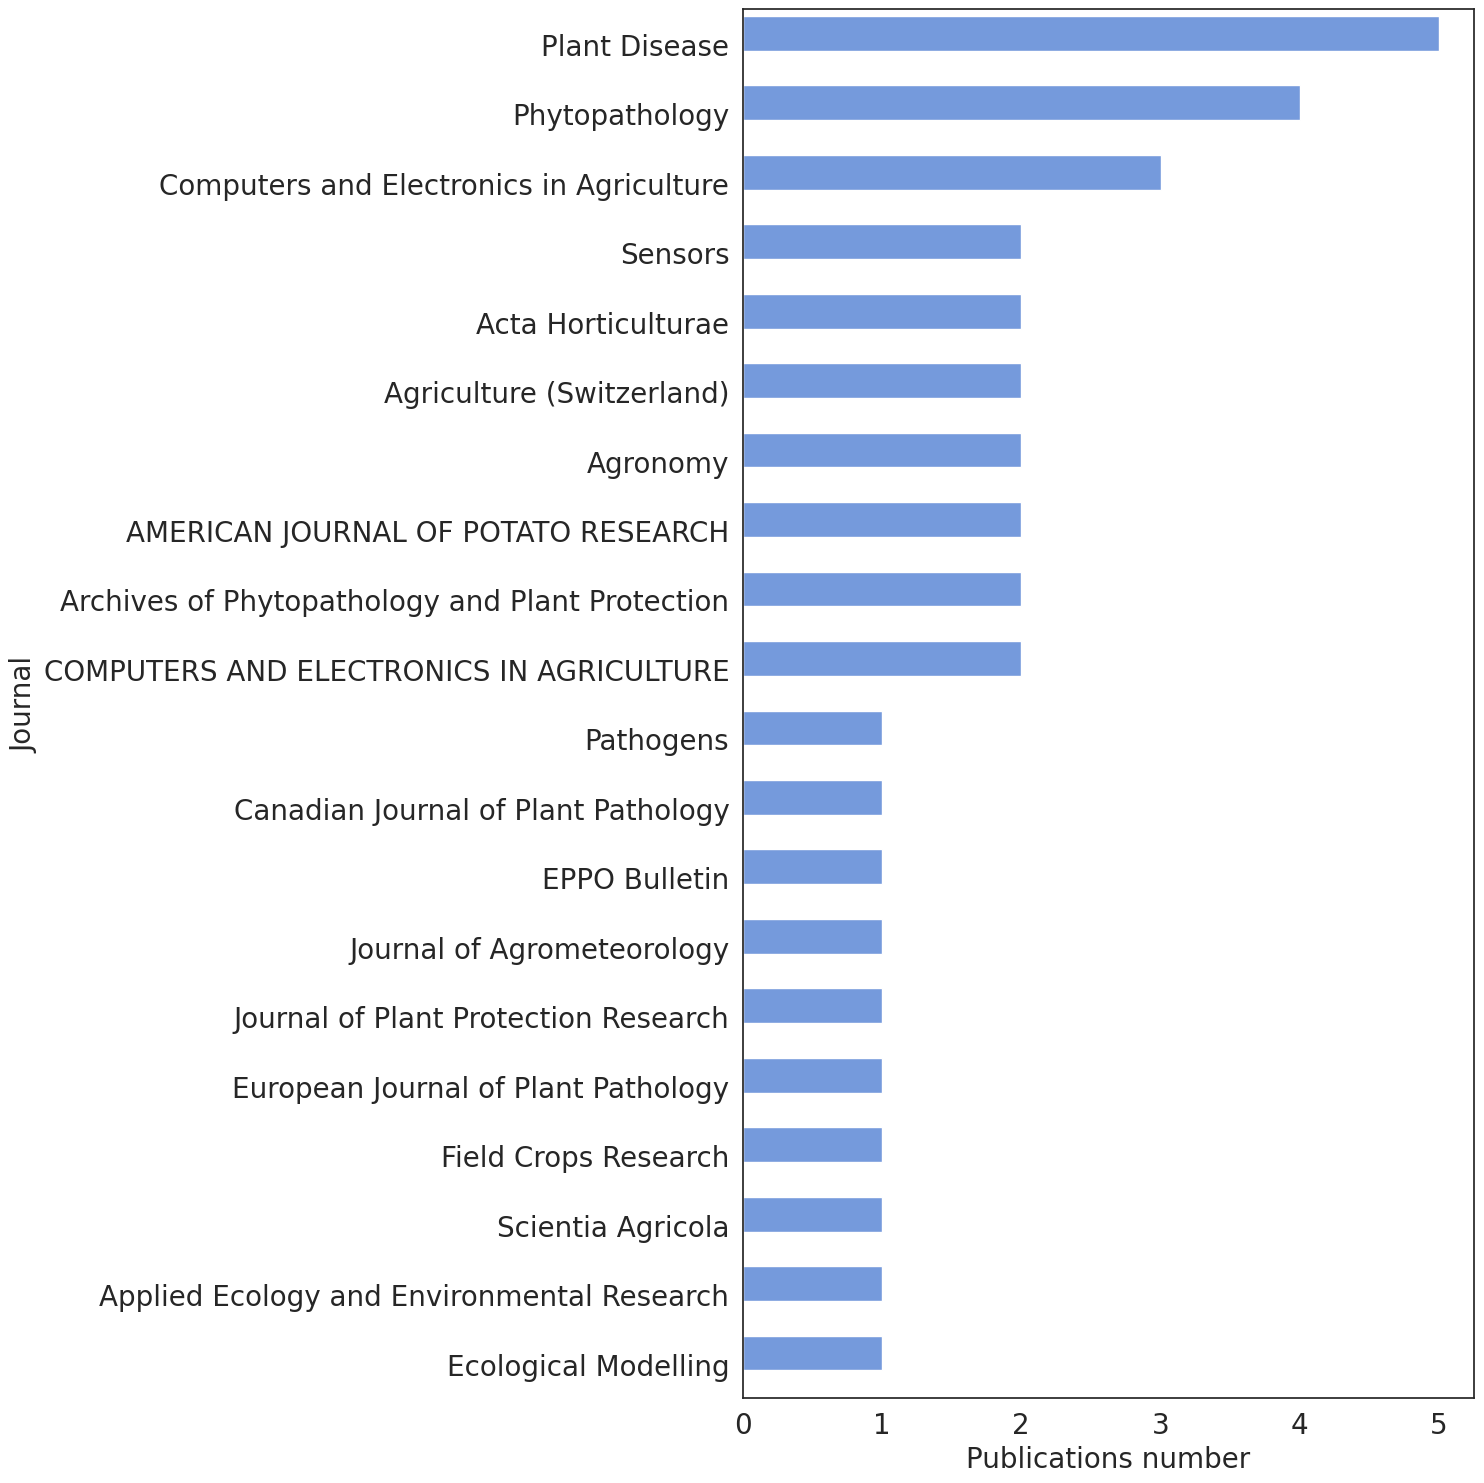

In [63]:
source_counts = data['Source title'].value_counts().nlargest(20)

def split_label(label, max_len=50):
    if len(label) <= max_len:
        return label
    else:
        words = label.split(' ')
        lines = []
        current_line = ''
        for word in words:
            if len(current_line) + len(word) + 1 <= max_len:
                current_line += (word + ' ')
            else:
                lines.append(current_line.strip())
                current_line = word + ' '
        lines.append(current_line.strip())
        return '\n'.join(lines)

labels = [split_label(label) for label in source_counts.index]

long_labels = any(len(label) > 10 for label in source_counts.index)

fig_height = 10 if long_labels else 6
bar_height = 0.5 if long_labels else 0.8

plt.figure(figsize=(15, 15))
ax = sns.barplot(y=source_counts.index, x=source_counts.values, color='cornflowerblue', height=bar_height)
ax.set_yticklabels(labels)

plt.ylabel('Journal', fontsize=20)
plt.xlabel('Publications number', fontsize=20)
plt.yticks(fontsize=20)
plt.xticks(fontsize=20)
plt.tight_layout()
plt.show()

/tmp/ipykernel_7074/3116396696.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels)


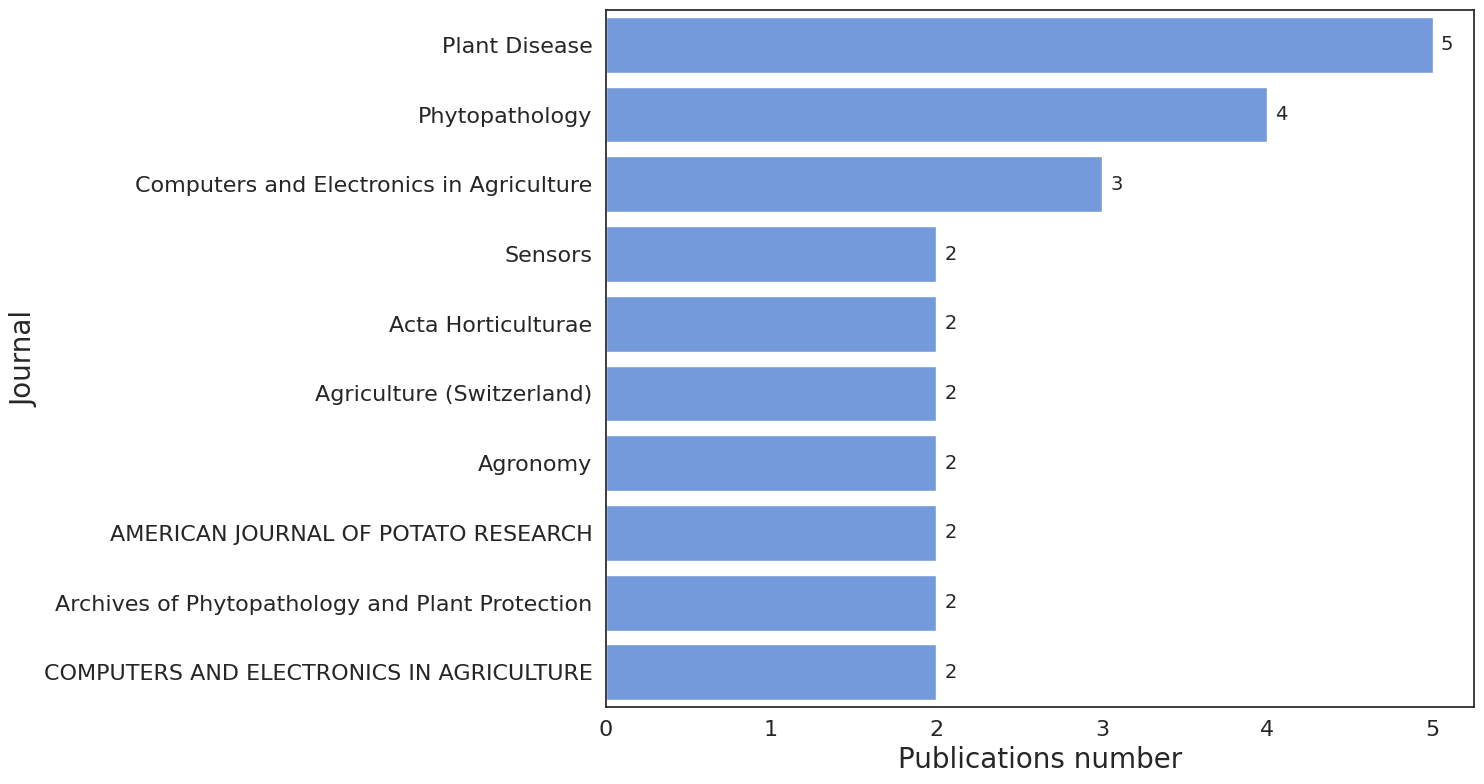

In [64]:
source_counts = data['Source title'].value_counts().nlargest(10)

def split_label(label, max_len=50):
    if len(label) <= max_len:
        return label
    else:
        words = label.split(' ')
        lines = []
        current_line = ''
        for word in words:
            if len(current_line) + len(word) + 1 <= max_len:
                current_line += (word + ' ')
            else:
                lines.append(current_line.strip())
                current_line = word + ' '
        lines.append(current_line.strip())
        return '\n'.join(lines)

labels = [split_label(label) for label in source_counts.index]

fig_height = 8

plt.figure(figsize=(15, fig_height))

ax = sns.barplot(
    y=source_counts.index,
    x=source_counts.values,
    color='cornflowerblue'
)

ax.set_yticklabels(labels)

for i, value in enumerate(source_counts.values):
    ax.text(
        value + max(source_counts.values)*0.01,
        i,
        str(value),
        va='center',
        fontsize=14
    )

ax.set_ylabel('Journal', fontsize=20)
ax.set_xlabel('Publications number', fontsize=20)

ax.tick_params(axis='both', labelsize=16)

plt.tight_layout()
plt.show()

Text(0.5, 0, 'Publications number')

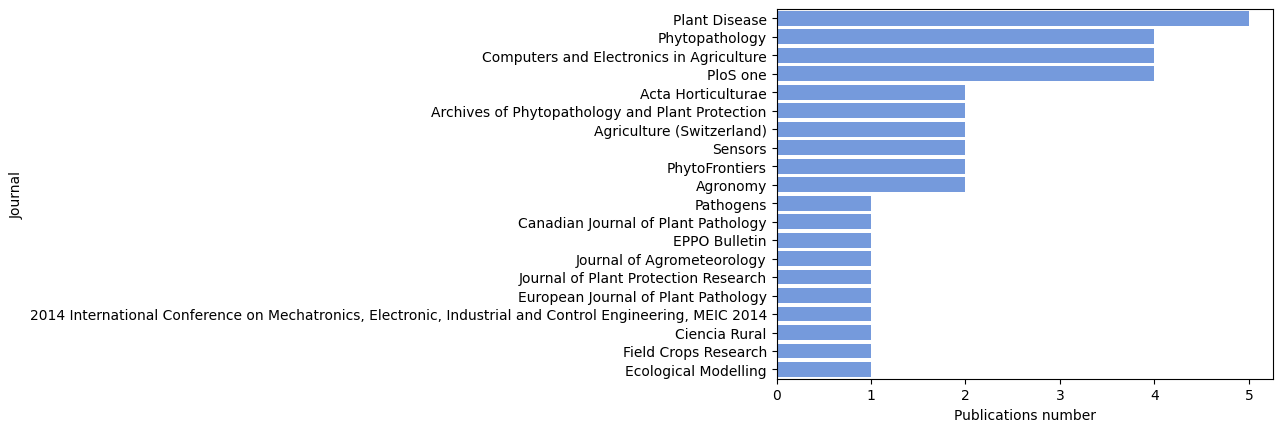

In [ ]:
source_counts = data['Source title'].value_counts().nlargest(20)
sns.barplot(y=source_counts.index, x=source_counts.values,color = 'cornflowerblue')
plt.ylabel('Journal')
plt.xlabel('Publications number')

In [ ]:
aut = data[['Source title']]
aut = aut.dropna()
data_c = []
text = " ; ".join(j for j in aut['Source title'])
data_c.append(text)
text = " ; ".join(j for j in data_c)

autores = [autor.strip() for autor in text.split(";")]
from collections import Counter
frecuencia_autores = Counter(autores)
top_autores = pd.DataFrame(frecuencia_autores.most_common(10))
top_autores.columns = ['aut','count']

import plotly.express as px
fig = px.treemap(top_autores, path=['aut'], values='count',
                 color='aut',
                 color_discrete_sequence=px.colors.qualitative.Pastel2) #https://improveandrepeat.com/2023/09/python-friday-193-choosing-colours-for-plotly/
fig.data[0].textinfo = 'label+value'
fig.update_layout(
    height=800,
    width=800,
    font_size=30
)
fig.show()

In [ ]:
len(frecuencia_autores)

51

In [ ]:
aut = data[['Authors']]
aut = aut.dropna()
data_c = []
text = " ; ".join(j for j in aut['Authors'])
data_c.append(text)
text = " ; ".join(j for j in data_c)

autores = [autor.strip() for autor in text.split(";")]
from collections import Counter
frecuencia_autores = Counter(autores)
top_autores = pd.DataFrame(frecuencia_autores.most_common(21))
top_autores.columns = ['aut','count']

import plotly.express as px
fig = px.treemap(top_autores, path=['aut'], values='count',
                 color='aut',
                 color_discrete_sequence=px.colors.qualitative.Pastel2) #https://improveandrepeat.com/2023/09/python-friday-193-choosing-colours-for-plotly/
fig.data[0].textinfo = 'label+value'
fig.update_layout(
    height=800,
    width=800,
    font_size=30
)
fig.show()

(array([0. , 0.5, 1. , 1.5, 2. , 2.5, 3. , 3.5]),
 [Text(0.0, 0, '0.0'),
  Text(0.5, 0, '0.5'),
  Text(1.0, 0, '1.0'),
  Text(1.5, 0, '1.5'),
  Text(2.0, 0, '2.0'),
  Text(2.5, 0, '2.5'),
  Text(3.0, 0, '3.0'),
  Text(3.5, 0, '3.5')])

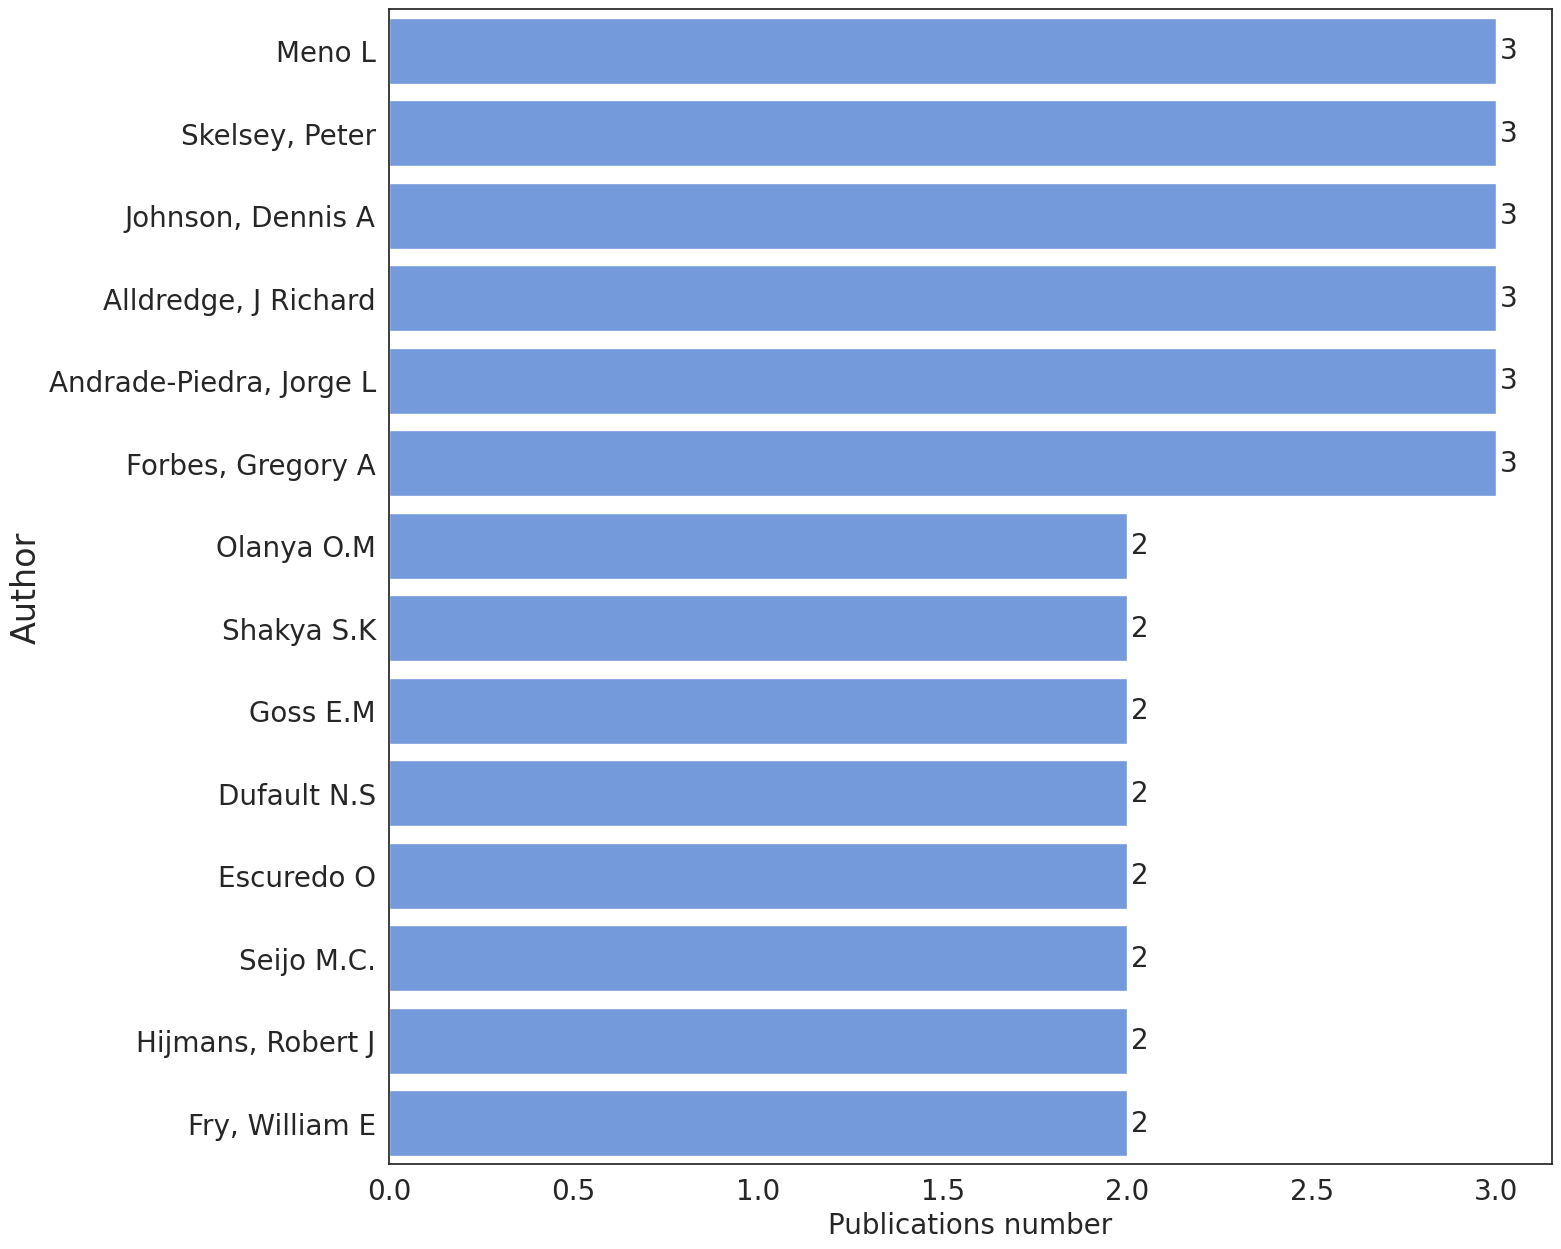

In [100]:
aut = data[['Authors','Group']]
aut = aut.dropna()
data_c = []
text = " ; ".join(j for j in aut['Authors'])
data_c.append(text)
text = " ; ".join(j for j in data_c)
autores = [autor.strip() for autor in text.split(";")]
frecuencia_autores = Counter(autores)
top_autores = pd.DataFrame(frecuencia_autores.most_common(15))
top_autores.columns = ['aut','count']
top_autores.drop(0,axis=0,inplace=True)

plt.figure(figsize=(15, 15))
ax = sns.barplot(
    data=top_autores,
    y='aut',
    x='count',
    color='cornflowerblue'
)

container = ax.containers[0]

ax.bar_label(
    container,
    fontsize=20,
    padding=3
)
plt.ylabel('Author',fontsize=24)
plt.xlabel('Publications number',fontsize=20)
plt.yticks(fontsize=20)
plt.xticks(fontsize=20)

Text(0.5, 0, 'Publications number')

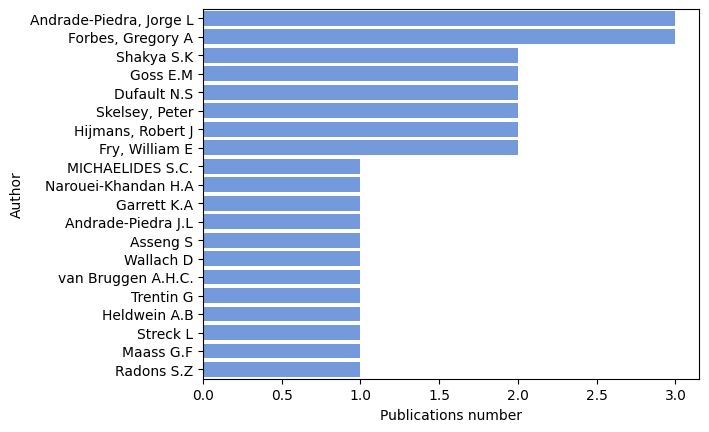

In [ ]:
aut = data[['Authors','Group']]
aut = aut.dropna()
aut = aut[aut['Group']=='Deterministic']
data_c = []
text = " ; ".join(j for j in aut['Authors'])
data_c.append(text)
text = " ; ".join(j for j in data_c)
autores = [autor.strip() for autor in text.split(";")]
frecuencia_autores = Counter(autores)
top_autores = pd.DataFrame(frecuencia_autores.most_common(21))
top_autores.columns = ['aut','count']
top_autores.drop(0,axis=0,inplace=True)
sns.barplot(data = top_autores, y='aut', x='count',color = 'cornflowerblue')
plt.ylabel('Author')
plt.xlabel('Publications number')

Text(0.5, 0, 'Publications number')

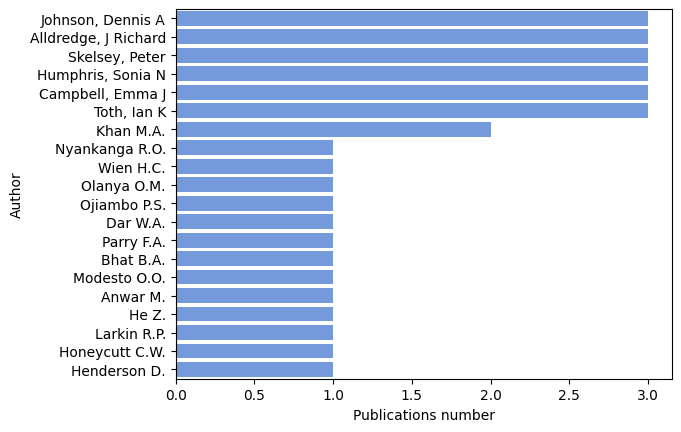

In [ ]:
aut = data[['Authors','Group']]
aut = aut.dropna()
aut = aut[aut['Group']=='Based on probability']
data_c = []
text = " ; ".join(j for j in aut['Authors'])
data_c.append(text)
text = " ; ".join(j for j in data_c)
autores = [autor.strip() for autor in text.split(";")]
frecuencia_autores = Counter(autores)
top_autores = pd.DataFrame(frecuencia_autores.most_common(21))
top_autores.columns = ['aut','count']
top_autores.drop(0,axis=0,inplace=True)
sns.barplot(data = top_autores, y='aut', x='count',color = 'cornflowerblue')
plt.ylabel('Author')
plt.xlabel('Publications number')

Text(0.5, 0, 'Publications number')

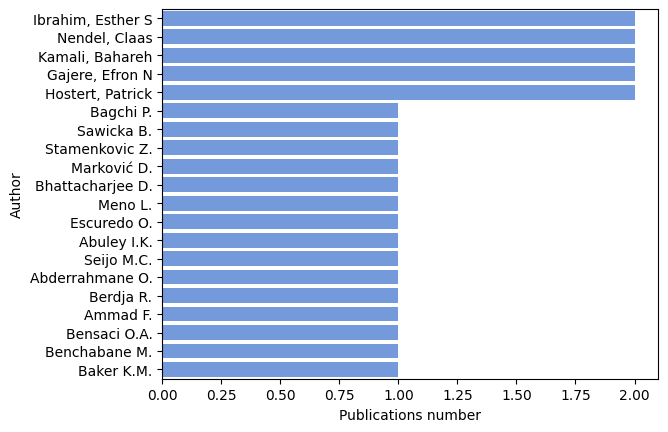

In [ ]:
aut = data[['Authors','Group']]
aut = aut.dropna()
aut = aut[aut['Group']=='Artificial Intelligence']
data_c = []
text = " ; ".join(j for j in aut['Authors'])
data_c.append(text)
text = " ; ".join(j for j in data_c)
autores = [autor.strip() for autor in text.split(";")]
frecuencia_autores = Counter(autores)
top_autores = pd.DataFrame(frecuencia_autores.most_common(21))
top_autores.columns = ['aut','count']
top_autores.drop(5,axis=0,inplace=True)
sns.barplot(data = top_autores, y='aut', x='count',color = 'cornflowerblue')
plt.ylabel('Author')
plt.xlabel('Publications number')

In [74]:
aut = data[['Country']]
aut = aut.dropna()
data_c = []
text = ";".join(j for j in aut['Country'])
data_c.append(text)
text = ";".join(j for j in data_c)
autores = [autor.strip() for autor in text.split(";")]
from collections import Counter
frecuencia_autores = Counter(autores)
paises = pd.DataFrame(autores, columns=['Pais'])
paises['Pais']

,Pais
0,United States of America
1,United States of America
2,Nigeria
3,India
4,India
...,...
200,France
201,United Kingdom
202,United Kingdom
203,United Kingdom


In [75]:
paises = paises['Pais'].value_counts().reset_index()

In [76]:
paises

,Pais,count
0,United States of America,54
1,United Kingdom,22
2,Brazil,11
3,Spain,11
4,Germany,11
5,Egypt,9
6,Belgium,9
7,Peru,8
8,France,7
9,Pakistan,6


Text(0.5, 0, 'Publications number')

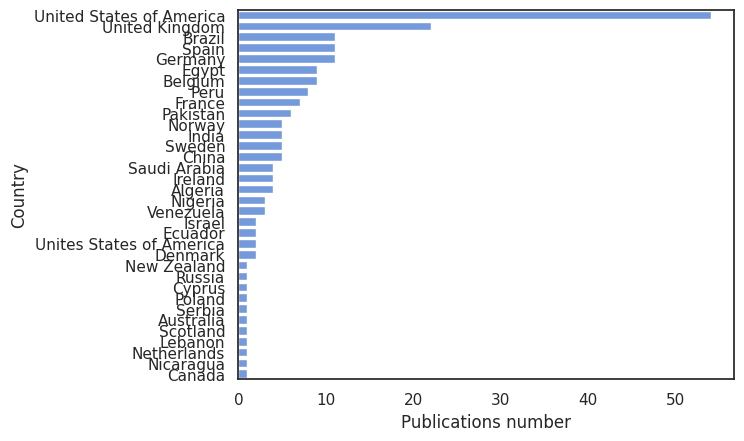

In [77]:
sns.barplot(data = paises, y='Pais', x='count',color = 'cornflowerblue')
plt.ylabel('Country')
plt.xlabel('Publications number')

In [86]:
df = paises

fig = px.choropleth(
    df,
    locations="Pais",
    locationmode="country names",
    color="count",
    color_continuous_scale="sunset",
)

fig.show()

In [97]:
df = paises.copy()
df["log_count"] = np.log1p(df["count"])

fig = px.choropleth(
    df,
    locations="Pais",
    locationmode="country names",
    color="log_count",
    color_continuous_scale="Viridis",
    hover_name="Pais",
    hover_data={"count": True, "log_count": False}
)

real_values = np.unique(np.round(np.linspace(df["count"].min(), df["count"].max(), 8)).astype(int))
log_values = np.log1p(real_values)

fig.update_coloraxes(
    colorbar=dict(
        title="Count",
        tickmode="array",
        tickvals=log_values,
        ticktext=[str(v) for v in real_values]
    )
)

fig.show()

In [96]:
df = paises.copy()
df["log_count"] = np.log1p(df["count"])

fig = px.choropleth(
    df,
    locations="Pais",
    locationmode="country names",
    color="log_count",
    color_continuous_scale="Cividis",
    hover_name="Pais",
    hover_data={"count": True, "log_count": False}
)

real_values = np.unique(np.round(np.linspace(df["count"].min(), df["count"].max(), 8)).astype(int))
log_values = np.log1p(real_values)

fig.update_coloraxes(
    colorbar=dict(
        title="Count",
        tickmode="array",
        tickvals=log_values,
        ticktext=[str(v) for v in real_values]
    )
)

fig.show()